# Jupyter Notebook_ Vinicius AV2

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_excel('Desktop/Faculdade/default_of_credit_card_clients__courseware_version_1_21_19.xls')


In [28]:
#Exercicio_1

bill_amt_features = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                     'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

pay_amt_features  = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
                     'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

print(bill_amt_features)
print(pay_amt_features)

['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [32]:
#Exercicio_2 Os valores médios fazem sentido para o limites de crédito, mas chama atenção que o crédito está a favor do cliente como demonstrado no minimo negativo.


df[bill_amt_features].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,50646.744233,48624.349167,4.649736e+04,42791.362167,39884.398167,38480.350933
std,73376.695080,70893.963498,6.910251e+04,64090.316188,60606.644833,59406.836932
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3234.000000,2682.000000,2.403000e+03,2034.000000,1534.000000,1080.000000
50%,21644.500000,20597.000000,1.975250e+04,18759.500000,17835.500000,16643.000000
75%,66148.500000,62999.750000,5.952675e+04,53572.250000,49804.000000,48863.500000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


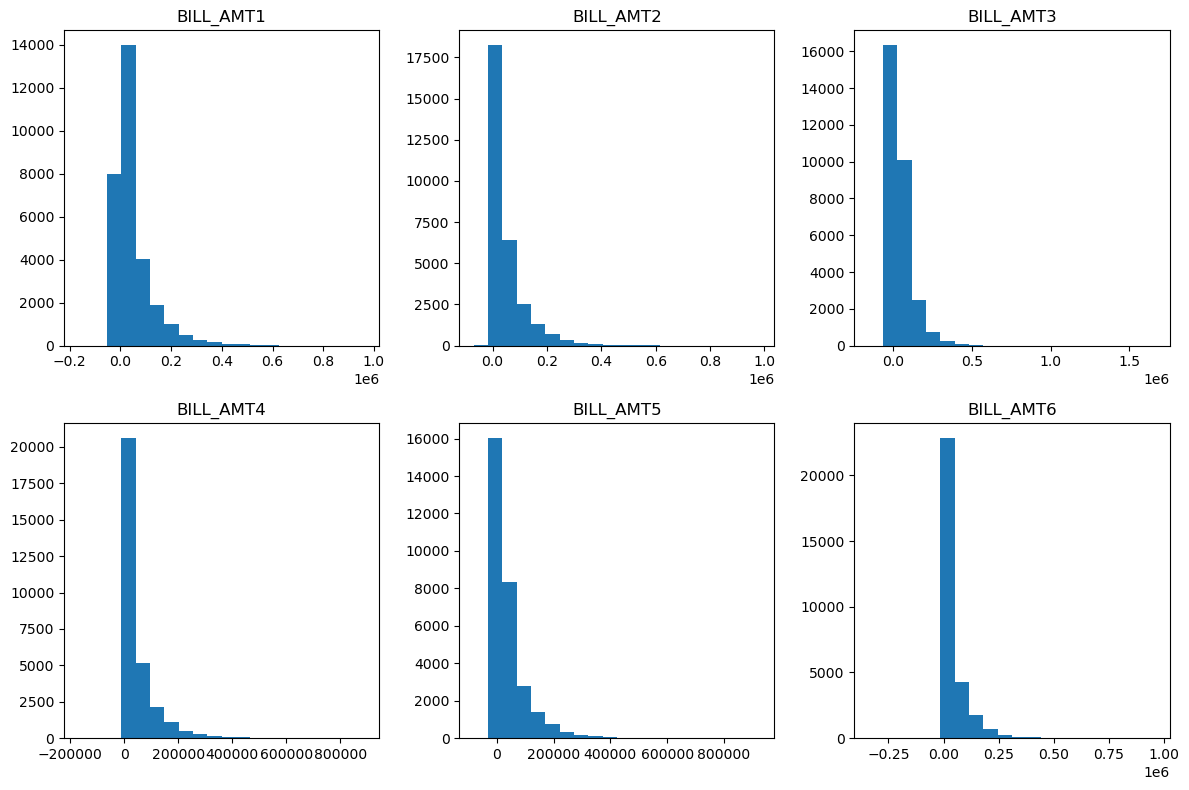

In [33]:
#Exercicio_3

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, col in zip(axes.flatten(), bill_amt_features):
    ax.hist(df[col], bins=20)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [43]:
#Exercicio_4 Sim, faz sentido já que o mínimo é 0 para as colunas, afinal há meses sem pagamentos

df[pay_amt_features].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000
mean,5613.321500,5.855410e+03,5174.387967,4776.089733,4754.749200,5164.223267
std,16539.094312,2.299256e+04,17565.538305,15532.893047,15239.070708,17712.664703
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,836.000000,7.217500e+02,371.000000,223.000000,170.750000,9.000000
50%,2084.500000,2.000000e+03,1776.000000,1500.000000,1500.000000,1500.000000
75%,5000.000000,5.000000e+03,4500.000000,4000.000000,4000.000000,4000.000000
max,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000


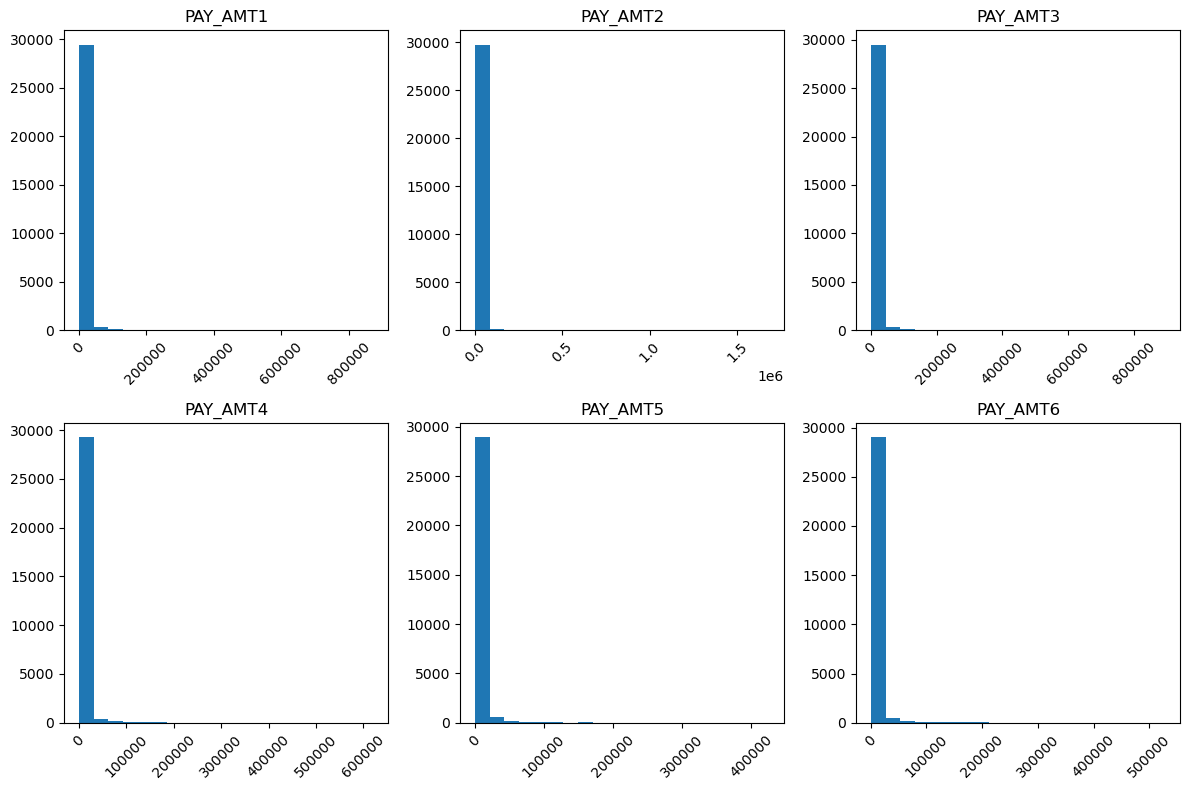

In [45]:
#Exercicio_5 As barras estão muito próximas do zero, mostrando que os pagamentos são muito baixos.

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, col in zip(axes.flatten(), pay_amt_features):
    ax.hist(df[col], bins=20)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [48]:
#Exercicio_6 Sim, esses números explicam a barra estar mais próxima do zero na atividade anterior

zero_mask = df[pay_amt_features] == 0

zero_mask.sum()

zero_mask.sum() / len(df) * 100

PAY_AMT1    18.346667
PAY_AMT2    18.876667
PAY_AMT3    20.743333
PAY_AMT4    22.200000
PAY_AMT5    23.183333
PAY_AMT6    24.720000
dtype: float64

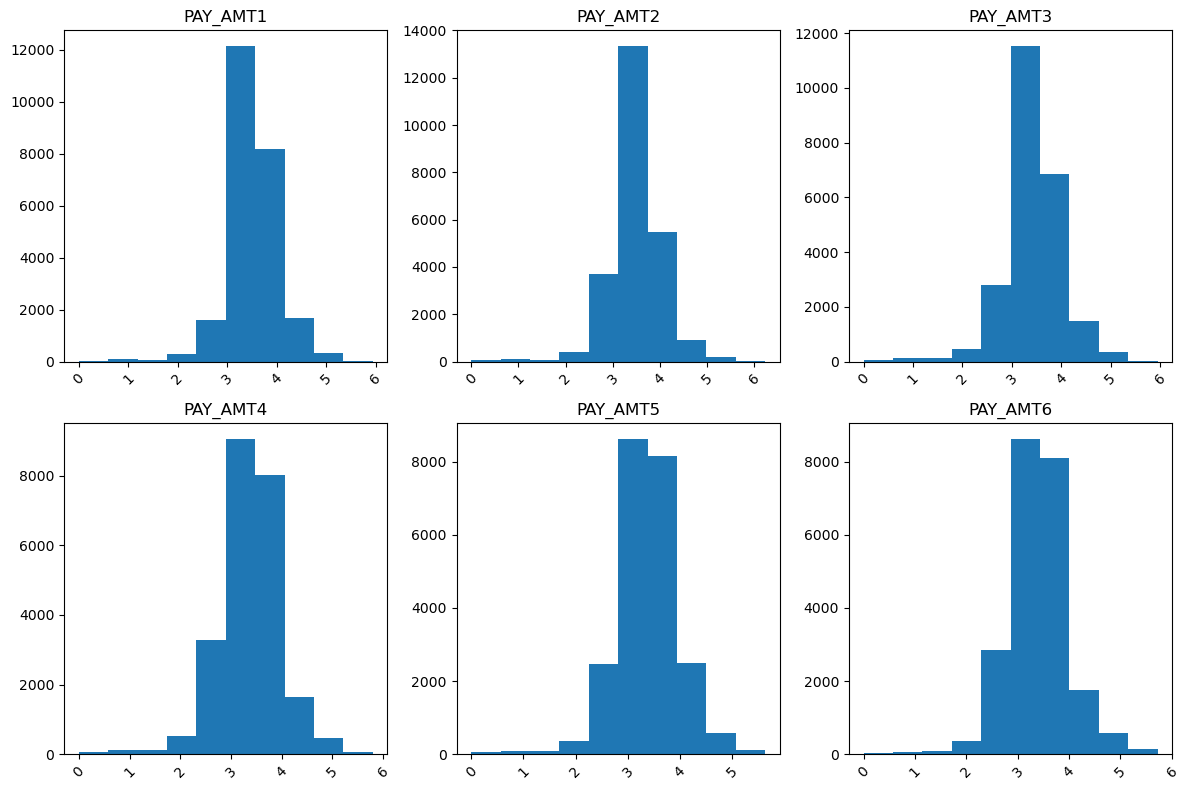

In [52]:
#Exercicio_7 As distribuições ficam muito semelhantes ao proposto no incio da atividade, utilizar o logaritimo se mostra o adequado para essa analise

nonzero_mask = df[pay_amt_features] != 0

log_pay = df[pay_amt_features][nonzero_mask].apply(np.log10)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, col in zip(axes.flatten(), pay_amt_features):
    ax.hist(log_pay[col].dropna(), bins=10)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()